# Oxygen Isotope Tracer: Science

This notebook is for investigating the characteristics of the oxygen isotope tracer data, built in the "case_study" notebook on the Arctic Ocean Reanalysis. In particular, we consider its relationship with the Antarctic Ocean Oscillation (AOO).

In [1]:
import yaml

import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

from source.nc_funcs import climdata, multiplot, timeseriesplot, climatology, anomaly, timeseg, weighted_average, timestep_da, xy_region

from source.mass_balance_functions import mass_fraction

with open("config.yaml", "r") as f:
    CONFIG = yaml.safe_load(f)

## 1. Load the data

The salinity data shown is from the Arctic Ocean Reanalysis (AOR) dataset. The δ¹⁸O dataset is trained on the AOR based on the Machine Learning model outlined in the `case_study.ipynb`. For this study, we'll focus on a 10m depth, which we have saved for the full time period.

The AOO index data is taken from `https://www2.whoi.edu/site/beaufortgyre/results/arctic-ocean-oscillation-index-aoo/`

In [26]:
# Load oyxgen isotope & salinity data
oxy_iso = climdata(CONFIG["arctic_reanalysis_oxy"], var="oxygen_isotope_tracer").sel(depth=2)
sal = climdata(CONFIG["arctic_reanalysis"], var="so").sel(depth=2)

In [27]:
# Create climatology and anomaly
## d18O
oxy_iso_clim = climatology(oxy_iso, "month")
oxy_iso_anom = anomaly(oxy_iso, oxy_iso_clim, "month")
## Salinity
sal_clim = climatology(sal, "month")
sal_anom = anomaly(sal, sal_clim, "month")

In [28]:
# Create timeseries by computing weighted average over lat/lon
## d18O
oxy_iso_tseries = weighted_average(oxy_iso, "longitude", "latitude")
oxy_iso_clim_tseries = weighted_average(oxy_iso_clim, "longitude", "latitude")
oxy_iso_anom_tseries = weighted_average(oxy_iso_anom, "longitude", "latitude")
## Salinity
sal_tseries = weighted_average(sal, "longitude", "latitude")
sal_clim_tseries = weighted_average(sal_clim, "longitude", "latitude")
sal_anom_tseries = weighted_average(sal_anom, "longitude", "latitude")

The AOO index measures the strength and direction (cyclonic or anticyclonic) of the wind driven circulation in the Arctic Ocean. It correlates strongly with the freshwater content in the Beaufort Gyre, which is centred on (150W, 75N) [Regan et. al., 2020].

In [29]:
# Load AOO data
aoo_df = pd.read_csv(CONFIG["aoo_index"], sep="|", index_col=0)
aoo_da = xr.DataArray(aoo_df["AOO Index"].values,coords={"time": pd.to_datetime(aoo_df["Year"], format="%Y")},dims="time",name="aoo_index")

Text(0, 0.5, 'AOO index')

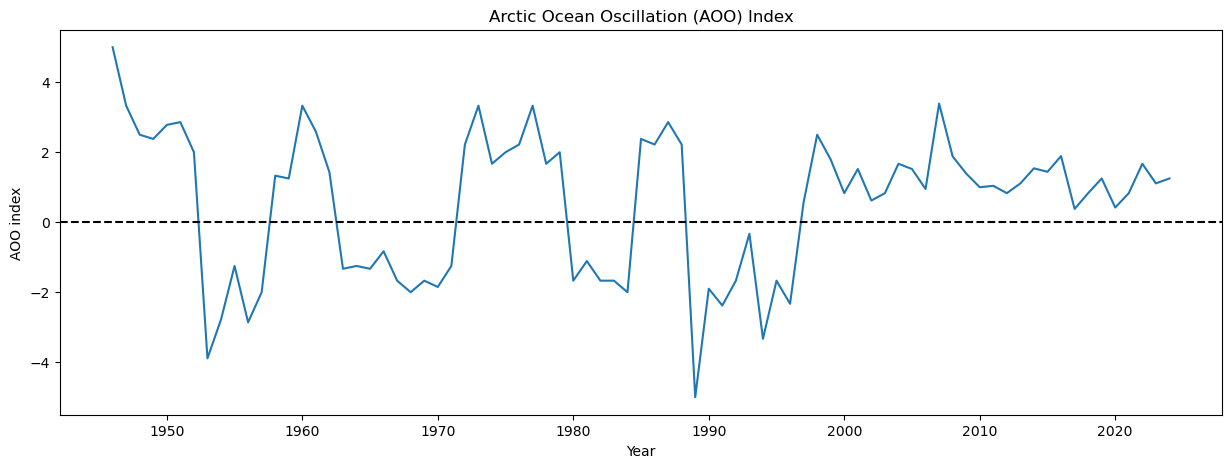

In [30]:
# Plot the AOO index (defined from the Beaufort Gyre Exploration Project)
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(aoo_df["Year"], aoo_df["AOO Index"])
ax.axhline(0, color="k", linestyle="--")
ax.set_title("Arctic Ocean Oscillation (AOO) Index")
ax.set_xlabel("Year")
ax.set_ylabel("AOO index")

## 2. δ¹⁸O Plots


### 2.1. Actuals

We consider some simple plots of the δ¹⁸O data for a low AOO (1994) and high AOO (2007).

In [8]:
oxy_neg_aoo = timeseg(oxy_iso, "time", ("1994-01-01", "1994-12-01"), Tstep="3mo")
oxy_pos_aoo = timeseg(oxy_iso, "time", ("2007-01-01", "2007-12-01"), Tstep="3mo")

AttributeError: module 'cartopy.feature' has no attribute 'feature'

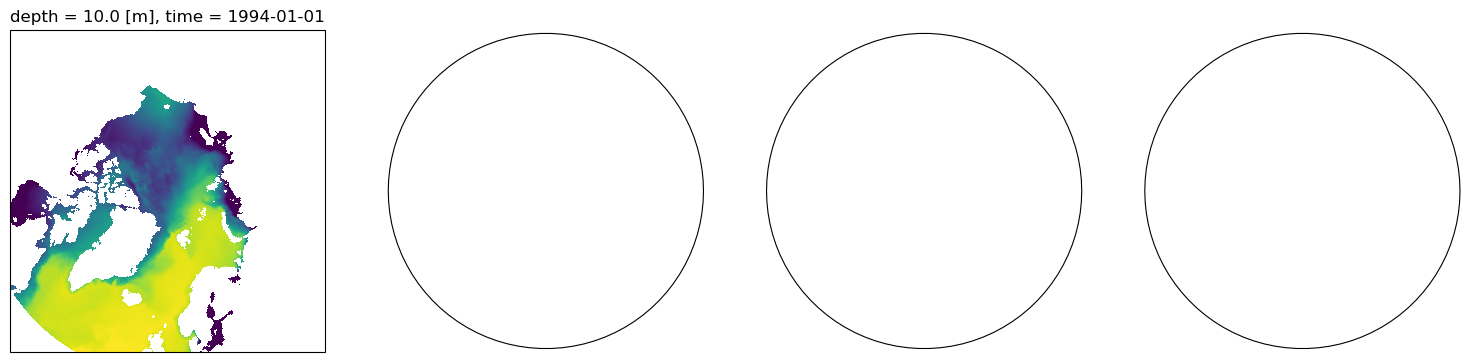

In [9]:
# Plot the 1994 data
fig, ax, p = multiplot(oxy_neg_aoo, ncol=4, vmin=-4, vmax=0.5, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(55,90)), cbar_label="δ¹⁸O (‰)", cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"}, figsize=(20, 6))

caption = "Fig. δ¹⁸O values from the AOR at a depth 10m for Jan, Apr, Jul, Oct in 1994."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Plot the 2007 data
fig, ax, p = multiplot(oxy_pos_aoo, ncol=4, vmin=-4, vmax=0.5, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(55,90)), cbar_label="δ¹⁸O (‰)", cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"}, figsize=(20, 6))

caption = "Fig. δ¹⁸O values from the AOR at a depth 10m for Jan, Apr, Jul, Oct in 2007."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Difference between 1994 & 2007
fig, ax, p = multiplot(oxy_pos_aoo.groupby('time.month').mean() - oxy_neg_aoo.groupby('time.month').mean(), tcoord="month", ncol=4, vmin=-1, vmax=1, cmap="RdBu_r", map_type="NorthPolarStereo", xyreg=(False,(55,90)), cbar_label="δ¹⁸O (‰)", cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"}, figsize=(20, 6))

caption = "Fig. Difference in δ¹⁸O values between 1994 & 2007 from the AOR at a depth 10m for Jan, Apr, Jul, Oct."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

### 2.2. Anomalies

In [10]:
oxy_neg_aoo_anom = timeseg(oxy_iso_anom, "time", ("1994-01-01", "1994-12-01"), Tstep="3mo")
oxy_pos_aoo_anom = timeseg(oxy_iso_anom, "time", ("2007-01-01", "2007-12-01"), Tstep="3mo")

AttributeError: module 'cartopy.feature' has no attribute 'feature'

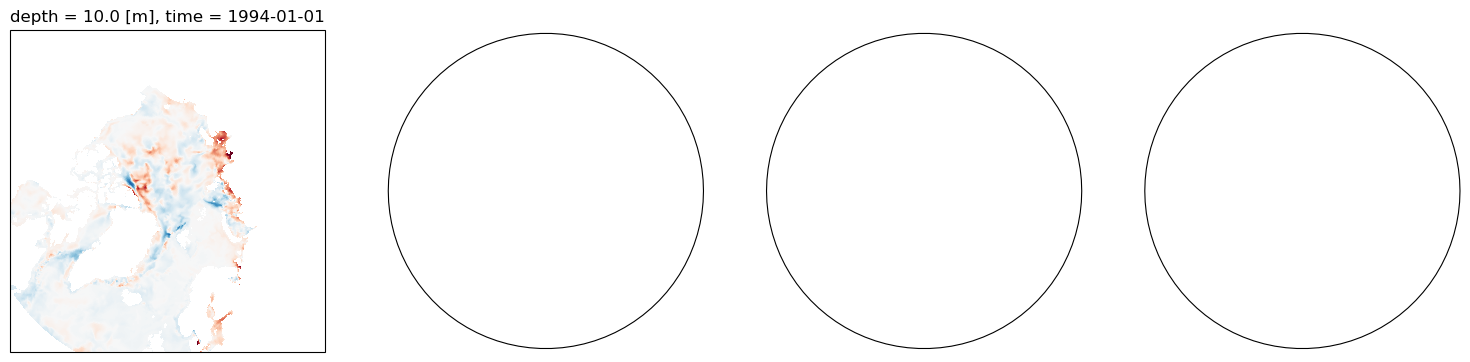

In [11]:
# Plot the 1994 data
fig, ax, p = multiplot(oxy_neg_aoo_anom, ncol=4, vmin=-1, vmax=1, cmap="RdBu_r", map_type="NorthPolarStereo", xyreg=(False,(55,90)), cbar_label="δ¹⁸O (‰)", cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"}, figsize=(20, 6))

caption = "Fig. δ¹⁸O anomaly values from the AOR at a depth 10m for Jan, Apr, Jul, Oct in 1994."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Plot the 2007 data
fig, ax, p = multiplot(oxy_pos_aoo_anom, ncol=4, vmin=-1, vmax=1, cmap="RdBu_r", map_type="NorthPolarStereo", xyreg=(False,(55,90)), cbar_label="δ¹⁸O (‰)", cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"}, figsize=(20, 6))

caption = "Fig. δ¹⁸O anomaly values from the AOR at a depth 10m for Jan, Apr, Jul, Oct in 2007."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

## 3. AOO Index & Gradients

We consider oxygen isotope freshwater tracer gradients emanating from the North Pole - how does it compare to the AOO?

Note: We tried doing it with gradients emanating from the centre of the Beaufort gyre (150W, 75N) but it showed a weak relationship with the AOO

In [31]:
# Take the mean across longitude for the region of interest (70-90N) and compute the annual mean
oxy_iso_da, lat_name, lon_name = oxy_iso_anom, "latitude", "longitude" 
oxy_anom_yr_lonav = timestep_da(xy_region(oxy_iso_da, lon_name, lat_name, False, (70,90)), "1y").mean(lon_name)

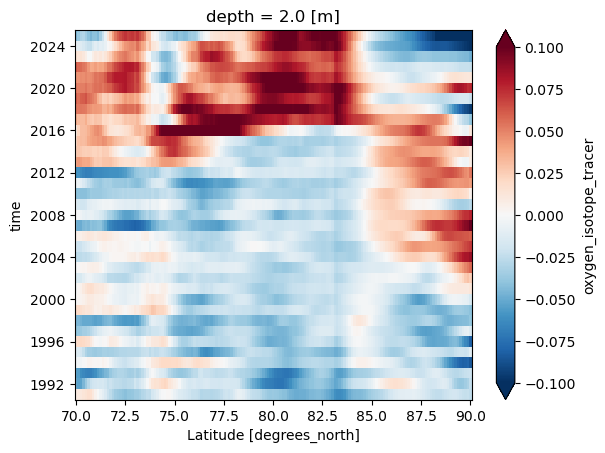

In [32]:
oxy_anom_yr_lonav.plot(vmin=-0.1, vmax=0.1, cmap="RdBu_r")

In [33]:
# Take the difference between the mean at each latitude and the mean at 90N to get the latitudinal gradient
oxy_anom_yr_latgrad = (oxy_anom_yr_lonav - oxy_anom_yr_lonav.sel({lat_name:90}))

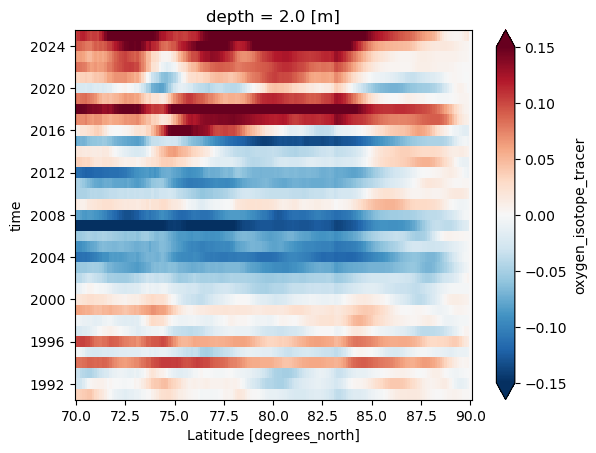

In [34]:
oxy_anom_yr_latgrad.plot(cmap="RdBu_r", vmin=-0.15, vmax=0.15)

In [35]:
# Take the mean across latitude to get the mean annual gradient. Take negative to more closely compare with AOO
oxy_anom_yr_grad = -1*oxy_anom_yr_latgrad.mean(lat_name)
print(oxy_anom_yr_grad)

<xarray.DataArray 'oxygen_isotope_tracer' (time: 35)> Size: 140B
array([ 0.00061111, -0.00145759,  0.01254021, -0.06905679,  0.01979359,
       -0.0597905 ,  0.01493561, -0.00494638, -0.02441584,  0.00410667,
        0.02484112,  0.04154864,  0.0692944 ,  0.08951749,  0.0719623 ,
        0.0609413 ,  0.12497575,  0.08832217, -0.01616362,  0.02382848,
        0.0585186 ,  0.06446832, -0.00403687,  0.0015464 ,  0.08454142,
       -0.03671585, -0.09099419, -0.14492944, -0.05738697,  0.01978671,
       -0.02847228, -0.05525644, -0.06645393, -0.11594135, -0.15009692],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 280B 1991-01-01 1992-01-01 ... 2025-01-01
    depth    float32 4B 2.0


Text(0, 0.5, 'AOO index')

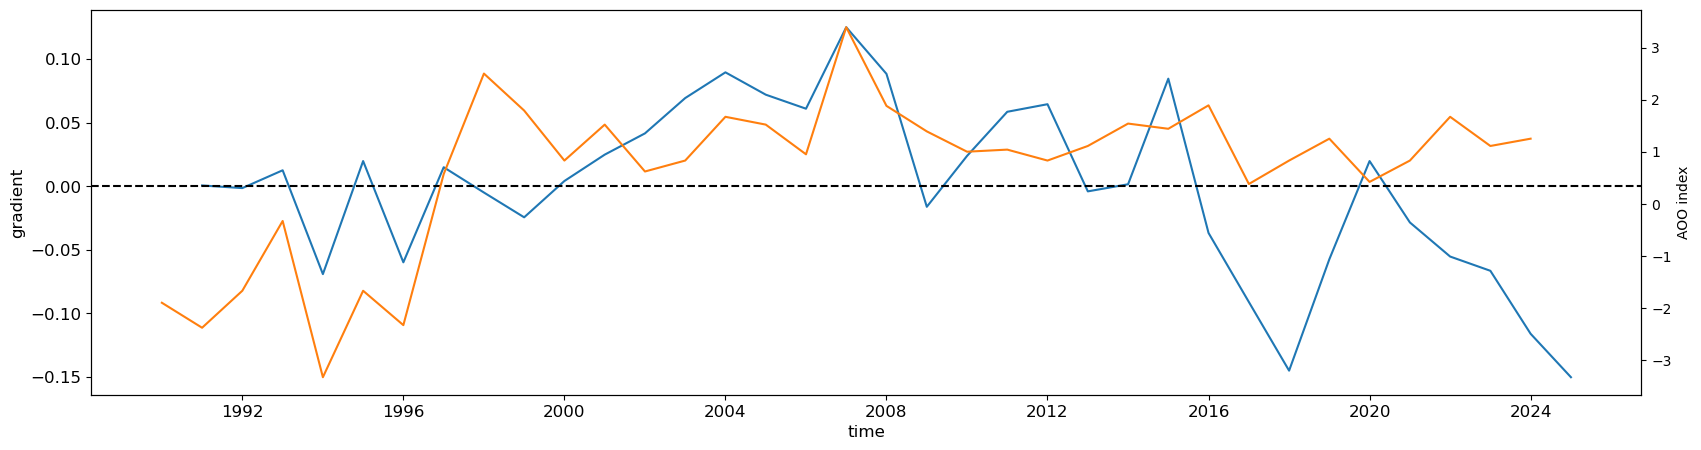

In [36]:
# Compare with the AOO index
fig, ax1, pl = timeseriesplot(oxy_anom_yr_grad, "gradient", "time", figsize=(20,5))
ax1.axhline(y=0, color="k", linestyle="--")

ax2 = ax1.twinx()
aoo_da_9024 = timeseg(aoo_da, "time", ("1990-01-01", "2024-01-01"))
aoo_da_9024.plot(ax=ax2, color="tab:orange")
ax2.set_ylabel("AOO index")


In [37]:
# Correlation between the AOO index and the mean annual gradient
corr_grad_aoo = xr.corr(timeseg(aoo_da, "time", ("1990-01-01", "2024-01-01")), oxy_anom_yr_grad, "time")
print("The correlation between the AOO index and the mean annual gradient in δ¹⁸O is:", corr_grad_aoo.values)

The correlation between the AOO index and the mean annual gradient in δ¹⁸O is: 0.2899033592692888


## 4. Mass Balance Fractions

We want to study the mass balance fractions using our oxygen isotope data

In [ ]:
# Compute the fractions relating to sea water, meteoric water & sea-ice
fsw, fmw, fsi = mass_fraction(oxy_iso=oxy_iso, sal=sal)

In [ ]:
fsw_season = timestep_da(fsw, "1sn")
fmw_season = timestep_da(fmw, "1sn")
fsi_season = timestep_da(fsi, "1sn")

In [ ]:
# Select the year to look at
y = 1994    # Low AOO

# Sea water
fig, ax, p = multiplot(timeseg(fsw_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0.7, vmax=1, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the seawater mass fraction at a depth 10m for {y} (low AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Meteoric water
fig, ax, p = multiplot(timeseg(fmw_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0, vmax=.3, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the meteoric water mass fraction at a depth 10m for {y} (low AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Sea-ice
fig, ax, p = multiplot(timeseg(fsi_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0, vmax=.2, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the sea-ice mass fraction at a depth 10m for {y} (low AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

In [ ]:
# Select the year to look at
y = 2007    # High AOO

# Sea water
fig, ax, p = multiplot(timeseg(fsw_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0.7, vmax=1, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the seawater mass fraction at a depth 10m for {y} (high AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Meteoric water
fig, ax, p = multiplot(timeseg(fmw_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0, vmax=.3, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the meteoric water mass fraction at a depth 10m for {y} (high AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)

# Sea-ice
fig, ax, p = multiplot(timeseg(fsi_season, "time", (f"{y}-01-01", f"{y}-12-01")), tcoord="time", ncol=4, nrow=1, figsize=(20,6), vmin=0, vmax=.2, cmap="viridis", map_type="NorthPolarStereo", xyreg=(False,(70,90)), cbar_label="mass fraction", subplot_title=["DJF", "MAM", "JJA", "SON"], cax_pos=(0.2,0.0,0.6,0.05), cbar_kws={"orientation": "horizontal"})

caption = f"Fig. Seasonal averages of the sea-ice mass fraction at a depth 10m for {y} (high AOO)."
tx = fig.text(0.5, -0.15, caption, ha="center", fontsize=10)